# Commodity Procurement Strategy Under Price Uncertainty
### When should a procurement manager buy, and what does waiting actually cost?

---

**Domain:** Supply chain / commodity procurement  
**Focus:** Minyak Goreng Curah (bulk cooking oil) - DKI Jakarta  
**Period:** April 2022 - September 2024  
**External signal:** WTI Crude Oil Futures + USD/IDR exchange rate

---

## TL;DR
Commodity price forecasting is routinely framed as a prediction problem: produce the most accurate price estimate. This notebook reframes it as a **decision problem**: given that the future is uncertain, which procurement strategy minimises cost exposure?

We build a full analytical pipeline, price history, volatility regimes, global-local price relationships, a forecasting model, and a backtested decision layer, that answers one concrete operational question:

> *"Under current market conditions, is it better to lock in today's price or wait 30 days?"*

The output is not a number. It is a **cost risk assessment**: the expected saving from waiting, the worst-case additional cost if the bet goes wrong, and the conditions under which each strategy dominates.

---
## 0. Setup

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

try:
    import lightgbm as lgb
    LGBM_AVAILABLE = True
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor
    LGBM_AVAILABLE = False
    print('LightGBM not found, falling back to sklearn GradientBoostingRegressor')

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_style('whitegrid')
PALETTE = {'low': '#2ecc71', 'medium': '#f39c12', 'high': '#e74c3c'}
print('Libraries loaded.')

Libraries loaded.


---
## 1. Data Loading & Preprocessing

Three sources are combined into a single daily panel:

| Source | Variable | Role |
|--------|----------|------|
| Harga Bahan Pangan | Minyak Goreng Curah - DKI Jakarta (IDR/kg) | **Prediction target** |
| Investing.com (WTI Futures) | Crude oil settlement price (USD/barrel) | Upstream cost signal |
| Yahoo Finance (USDIDR=X) | USD/IDR exchange rate | Currency alignment |

WTI and the exchange rate are forward-filled across non-trading days to align with the daily food price series.

In [42]:
# --- Minyak Goreng Curah: DKI Jakarta ---
mg_raw = pd.read_csv(
    '../Harga Bahan Pangan/train/Minyak Goreng Curah.csv',
    parse_dates=['Date']
)
mg = mg_raw[['Date', 'DKI Jakarta']].copy()
mg.columns = ['date', 'mg_price']
mg = mg.set_index('date').sort_index()
mg = mg.dropna(subset=['mg_price'])

# --- WTI Crude Oil Futures ---
wti_raw = pd.read_csv(
    '../Global Commodity Price/Crude Oil WTI Futures Historical Data.csv',
    parse_dates=['Date']
)
wti = wti_raw[['Date', 'Price']].copy()
wti.columns = ['date', 'wti_usd']
wti['wti_usd'] = pd.to_numeric(wti['wti_usd'], errors='coerce')
wti = wti.set_index('date').sort_index()

# --- USD/IDR exchange rate ---
fx_raw = pd.read_csv(
    '../Mata Uang/USDIDR=X.csv',
    parse_dates=['Date']
)
fx = fx_raw[['Date', 'Close']].copy()
fx.columns = ['date', 'usdidr']
fx = fx.set_index('date').sort_index()

# --- Merge on daily date index (MG data as anchor) ---
df = mg.copy()
df = df.join(wti, how='left')
df = df.join(fx, how='left')

# WTI trades only on weekdays - forward-fill gaps
df['wti_usd'] = df['wti_usd'].ffill()
df['usdidr'] = df['usdidr'].ffill()

# WTI in IDR terms (per barrel)
df['wti_idr'] = df['wti_usd'] * df['usdidr']

print(f'Dataset: {len(df):,} days  |  {df.index.min().date()} -> {df.index.max().date()}')
print(f'MG price range: IDR {df.mg_price.min():,.0f} - {df.mg_price.max():,.0f}/kg')
print(f'WTI range: USD {df.wti_usd.min():.1f} - {df.wti_usd.max():.1f}/barrel')
df.head(3)

Dataset: 856 days  |  2022-04-21 -> 2024-09-30
MG price range: IDR 13,940 - 21,900/kg
WTI range: USD 65.1 - 119.8/barrel


,mg_price,wti_usd,usdidr,wti_idr
date,,,,
2022-04-21,19720.0,102.96,14351.0,1477578.96
2022-04-22,19630.0,101.05,14382.0,1453301.10
2022-04-23,19630.0,101.05,14382.0,1453301.10


---
## 2. Exploratory Data Analysis

Two immediate observations stand out from the raw data: both cooking oil and crude oil prices **peaked in mid-2022 and have trended downward since**, and prices show **consistent seasonal elevation during Ramadan** (March-May). These two patterns - trend and seasonality - will be the backbone of the forecasting model.

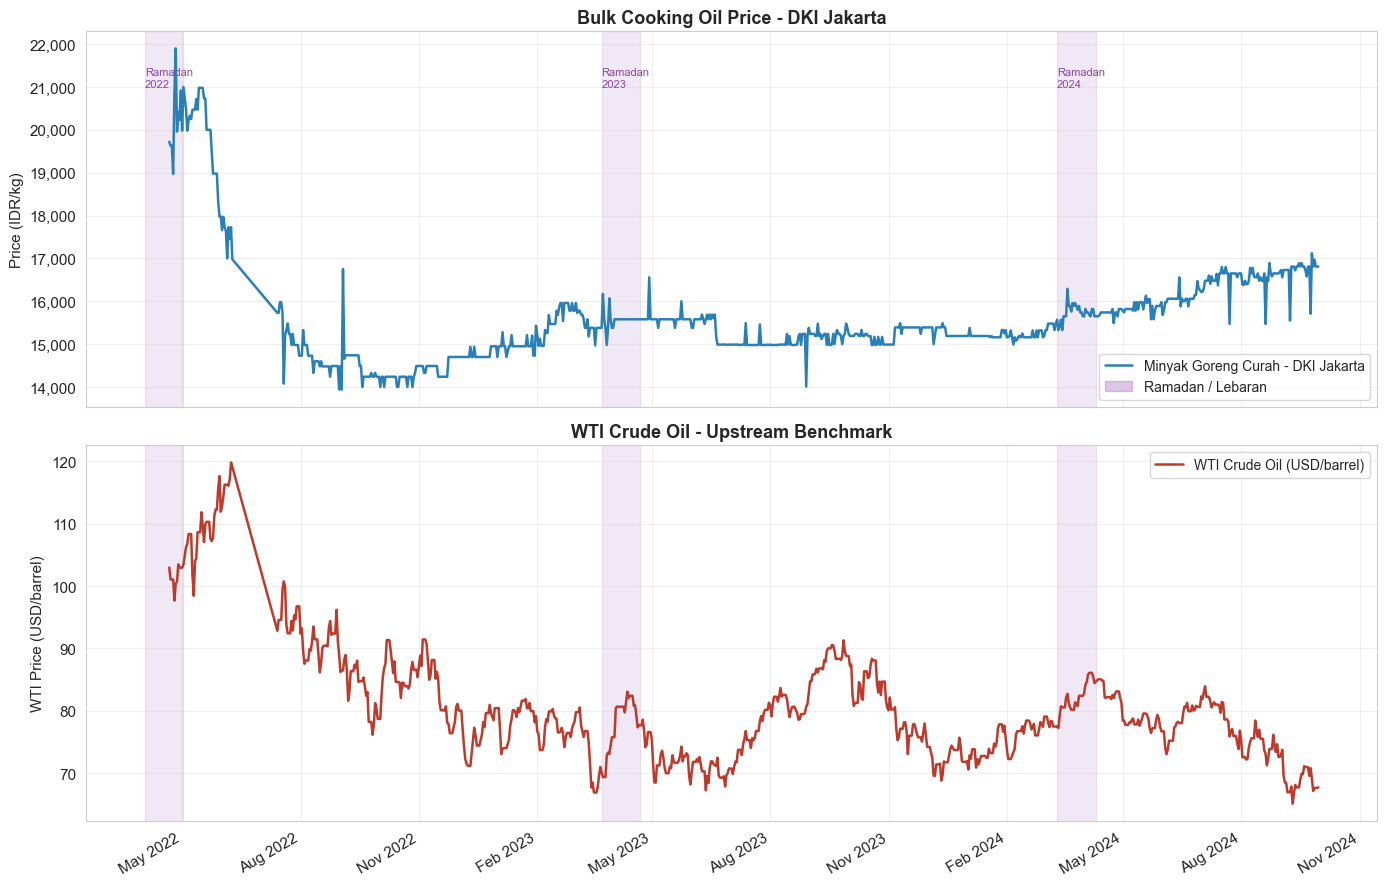

Both series declined from 2022 peaks. Ramadan periods (purple) show visible price pressure.


In [43]:
# Ramadan / Lebaran periods - key seasonal driver for Indonesian food prices
ramadan_periods = [
    ('2022-04-02', '2022-05-02', 'Ramadan\n2022'),
    ('2023-03-23', '2023-04-22', 'Ramadan\n2023'),
    ('2024-03-11', '2024-04-10', 'Ramadan\n2024'),
]

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Top: Minyak Goreng price
ax1 = axes[0]
ax1.plot(df.index, df['mg_price'], color='#2980b9', linewidth=1.8, label='Minyak Goreng Curah - DKI Jakarta')
ax1.set_ylabel('Price (IDR/kg)', fontsize=11)
ax1.set_title('Bulk Cooking Oil Price - DKI Jakarta', fontsize=13, fontweight='bold')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Bottom: WTI crude oil (IDR equivalent)
ax2 = axes[1]
ax2.plot(df.index, df['wti_usd'], color='#c0392b', linewidth=1.8, label='WTI Crude Oil (USD/barrel)')
ax2.set_ylabel('WTI Price (USD/barrel)', fontsize=11)
ax2.set_title('WTI Crude Oil - Upstream Benchmark', fontsize=13, fontweight='bold')

# Shade Ramadan periods on both axes
for start, end, label in ramadan_periods:
    for ax in axes:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.12, color='#8e44ad', zorder=0)
    axes[0].text(pd.Timestamp(start), df['mg_price'].max() * 0.98,
                 label, fontsize=8, color='#8e44ad', va='top')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

ramadan_patch = mpatches.Patch(color='#8e44ad', alpha=0.3, label='Ramadan / Lebaran')
axes[0].legend(handles=[axes[0].lines[0], ramadan_patch], fontsize=10)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('price_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Both series declined from 2022 peaks. Ramadan periods (purple) show visible price pressure.')

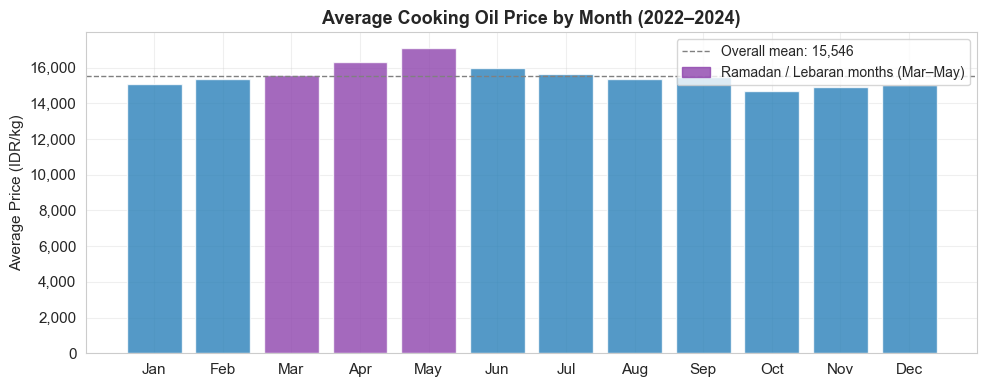

March-May shows elevated average prices, consistent with Ramadan demand effects.


In [44]:
# Monthly seasonality - average price by month across all years
df['month'] = df.index.month
df['year'] = df.index.year

monthly_avg = df.groupby('month')['mg_price'].mean()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(1, 13), monthly_avg.values,
              color=['#8e44ad' if m in [3, 4, 5] else '#2980b9' for m in range(1, 13)],
              alpha=0.8, edgecolor='white')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_ylabel('Average Price (IDR/kg)')
ax.set_title('Average Cooking Oil Price by Month (2022-2024)', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.axhline(monthly_avg.mean(), color='gray', linestyle='--', linewidth=1, label=f'Overall mean: {monthly_avg.mean():,.0f}')

ramadan_patch = mpatches.Patch(color='#8e44ad', alpha=0.8, label='Ramadan / Lebaran months (Mar-May)')
ax.legend(handles=[ax.lines[0], ramadan_patch], fontsize=10)
plt.tight_layout()
plt.savefig('monthly_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()
print('March-May shows elevated average prices, consistent with Ramadan demand effects.')

---
## 3. Volatility Regime Analysis

Price *level* is only half the picture. A high average price with low day-to-day variance is far easier to plan around than a lower average with unpredictable swings.

We classify each trading day into one of three **volatility regimes** based on the 30-day rolling standard deviation of price, and show how the regime has evolved over the analysis period. The current regime directly informs the decision in Section 6.

| Regime | Rolling Std (30-day) | Procurement interpretation |
|--------|---------------------|---------------------------|
| Low | < 33rd percentile | Lock in price when convenient - little urgency |
| Medium | 33rd - 67th percentile | Monitor closely; lean towards buying sooner |
| High | > 67th percentile | Price certainty has real value - consider buying now |

In [45]:
# Rolling volatility (30-day standard deviation of daily price)
df['rolling_std_30'] = df['mg_price'].rolling(window=30, min_periods=15).std()
df['rolling_mean_30'] = df['mg_price'].rolling(window=30, min_periods=15).mean()

# Coefficient of variation (normalised volatility)
df['rolling_cv'] = df['rolling_std_30'] / df['rolling_mean_30']

# Regime classification
p33 = df['rolling_std_30'].quantile(0.33)
p67 = df['rolling_std_30'].quantile(0.67)

def classify_regime(std):
    if pd.isna(std):
        return 'low'
    if std < p33:
        return 'low'
    elif std < p67:
        return 'medium'
    else:
        return 'high'

df['regime'] = df['rolling_std_30'].apply(classify_regime)

regime_counts = df['regime'].value_counts(normalize=True) * 100
print('Volatility regime distribution:')
for r in ['low', 'medium', 'high']:
    print(f'  {r.capitalize():8s}: {regime_counts.get(r, 0):.1f}% of trading days')

print(f'\nCurrent regime (last 30 days): {df["regime"].iloc[-1].upper()}')
print(f'Current rolling std: IDR {df["rolling_std_30"].iloc[-1]:,.0f}/kg')

Volatility regime distribution:
  Low     : 34.1% of trading days
  Medium  : 33.4% of trading days
  High    : 32.5% of trading days

Current regime (last 30 days): HIGH
Current rolling std: IDR 312/kg


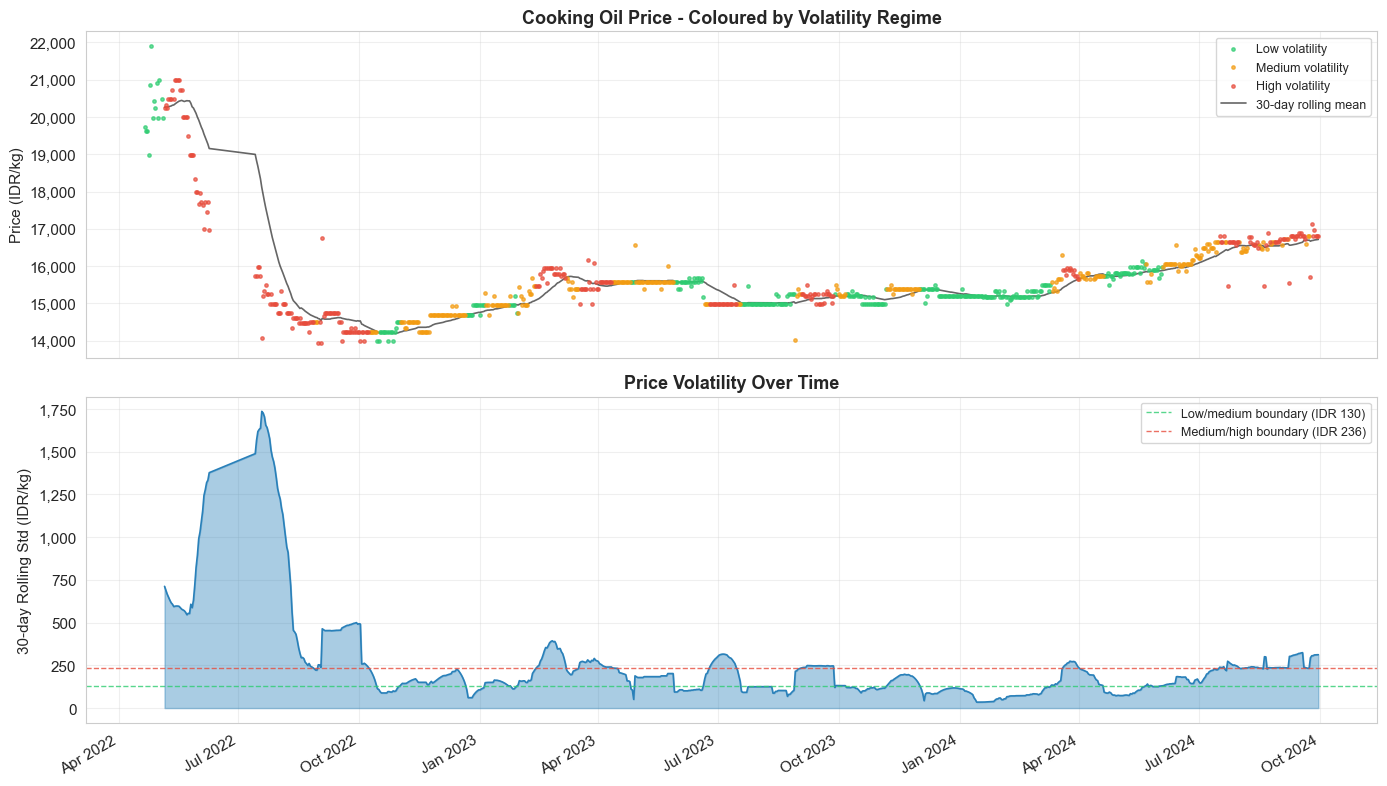

In [46]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Price coloured by regime
for regime, color in PALETTE.items():
    mask = df['regime'] == regime
    ax1.scatter(df.index[mask], df['mg_price'][mask],
                c=color, s=6, alpha=0.7, label=f'{regime.capitalize()} volatility', zorder=3)
ax1.plot(df.index, df['rolling_mean_30'], color='black', linewidth=1.2,
         alpha=0.6, label='30-day rolling mean', zorder=2)
ax1.set_ylabel('Price (IDR/kg)')
ax1.set_title('Cooking Oil Price - Coloured by Volatility Regime', fontsize=13, fontweight='bold')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.legend(fontsize=9, loc='upper right')

# Rolling std
ax2.fill_between(df.index, df['rolling_std_30'], alpha=0.4, color='#2980b9')
ax2.plot(df.index, df['rolling_std_30'], color='#2980b9', linewidth=1.2)
ax2.axhline(p33, color=PALETTE['low'], linestyle='--', linewidth=1, alpha=0.8, label=f'Low/medium boundary (IDR {p33:,.0f})')
ax2.axhline(p67, color=PALETTE['high'], linestyle='--', linewidth=1, alpha=0.8, label=f'Medium/high boundary (IDR {p67:,.0f})')
ax2.set_ylabel('30-day Rolling Std (IDR/kg)')
ax2.set_title('Price Volatility Over Time', fontsize=13, fontweight='bold')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('volatility_regime.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Global-Local Price Relationship

Cooking oil in Indonesia is derived primarily from palm oil. Its cost structure spans crude oil (energy for harvest and processing), shipping, and domestic supply chains - all of which are correlated with global energy markets.

We examine whether WTI crude oil movements are detectable in local retail cooking oil prices.

**What the data shows:** The cross-correlation analysis reveals a moderate positive relationship (r ~ 0.50). Notably, the strongest correlation occurs at a **negative lag**, meaning Jakarta retail cooking oil prices appear to move *slightly ahead* of WTI futures, not behind them.

This is counterintuitive but interpretable: Indonesian retail prices are influenced by palm oil supply policy (Indonesia is the world's largest palm oil producer), and local price adjustments can precede their eventual reflection in global energy futures through biofuel demand channels. It also reflects the "stickiness" of regulated retail prices; they adjust in discrete steps rather than continuously.

**Practical implication for procurement:** WTI is not a reliable leading indicator for retail cooking oil timing in this dataset. The more actionable signals are **local price trend and volatility regime**, which Section 6 uses directly.

> *We do not claim causality in either direction. Both series are plausibly driven by shared macroeconomic conditions: global demand, USD strength, and energy transition dynamics.*

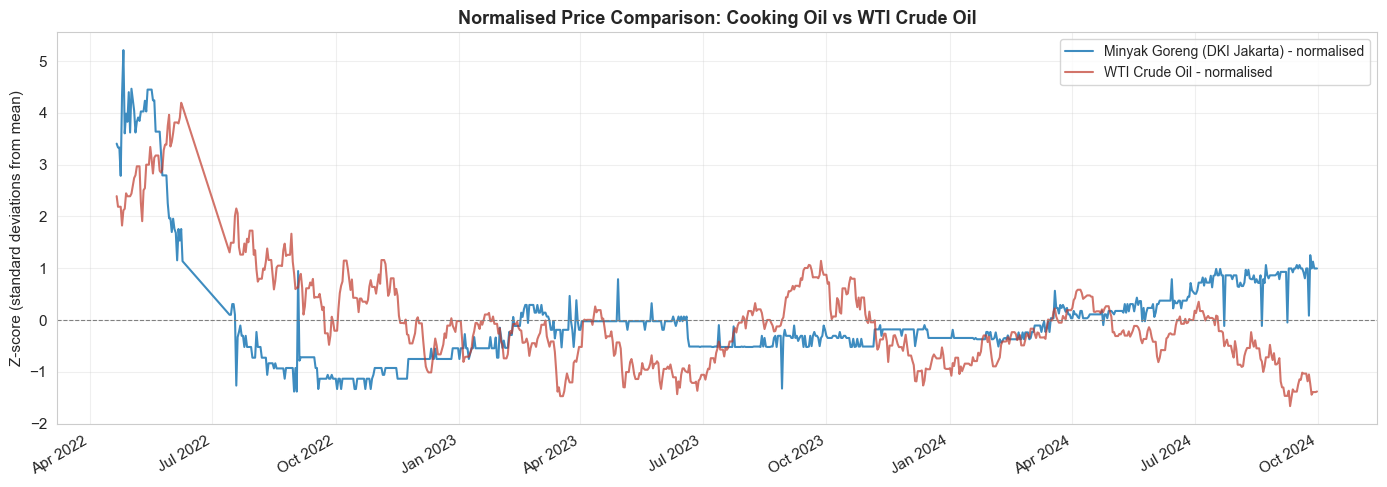

In [47]:
# Normalise both series to z-scores for visual comparison
df_clean = df[['mg_price', 'wti_usd']].dropna()

mg_z = (df_clean['mg_price'] - df_clean['mg_price'].mean()) / df_clean['mg_price'].std()
wti_z = (df_clean['wti_usd'] - df_clean['wti_usd'].mean()) / df_clean['wti_usd'].std()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_clean.index, mg_z, color='#2980b9', linewidth=1.5, label='Minyak Goreng (DKI Jakarta) - normalised', alpha=0.9)
ax.plot(df_clean.index, wti_z, color='#c0392b', linewidth=1.5, label='WTI Crude Oil - normalised', alpha=0.7)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_ylabel('Z-score (standard deviations from mean)')
ax.set_title('Normalised Price Comparison: Cooking Oil vs WTI Crude Oil', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('normalised_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

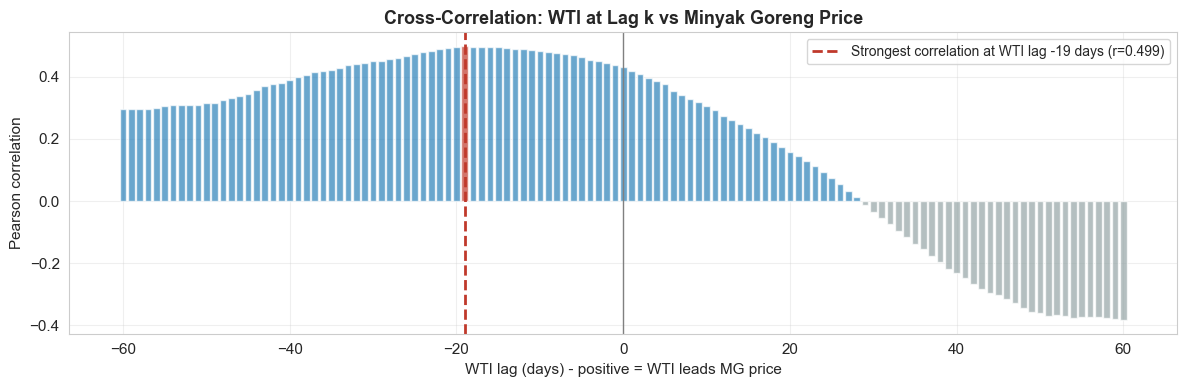

Observation: WTI at lag -19 days correlates most strongly with cooking oil price (r=0.499)
Both series appear to move contemporaneously or MG leads WTI in this dataset.


In [48]:
# Cross-correlation: does WTI at lag k correlate with MG price today?
max_lag = 60  # days
lags = range(-max_lag, max_lag + 1)
correlations = [
    df_clean['mg_price'].corr(df_clean['wti_usd'].shift(lag))
    for lag in lags
]

best_lag = lags[np.argmax(correlations)]
best_corr = max(correlations)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(list(lags), correlations, color=[
    '#c0392b' if c == best_corr else ('#2980b9' if c > 0 else '#95a5a6')
    for c in correlations
], alpha=0.7, width=0.8)
ax.axvline(best_lag, color='#c0392b', linewidth=2, linestyle='--',
           label=f'Strongest correlation at WTI lag {best_lag:+d} days (r={best_corr:.3f})')
ax.axvline(0, color='gray', linewidth=1)
ax.set_xlabel('WTI lag (days) - positive = WTI leads MG price')
ax.set_ylabel('Pearson correlation')
ax.set_title('Cross-Correlation: WTI at Lag k vs Minyak Goreng Price', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('cross_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Observation: WTI at lag {best_lag:+d} days correlates most strongly with cooking oil price (r={best_corr:.3f})')
if best_lag > 0:
    print(f'This suggests WTI movements tend to precede local price changes by ~{best_lag} days.')
    print('Interpretation: global oil price signals may provide a forward-looking procurement signal.')
else:
    print('Both series appear to move contemporaneously or MG leads WTI in this dataset.')

---
## 5. Price Forecasting with Scenario Bands

A forecast is required to generate forward-looking cost scenarios for the decision layer. The goal here is **not** to win a prediction competition - it is to produce a calibrated uncertainty range that makes the decision framework honest.

**Model:** LightGBM with lag features, rolling statistics, calendar features, and a Ramadan indicator.

**Validation:** Trained on April 2022 - June 2024, validated on July-September 2024 (the most recent 3 months of available data).

**What 1.70% MAPE means in practice:** At a current price of IDR 16,810/kg, the model's typical error is ~IDR 286/kg. For a 10,000 kg monthly procurement, that is ~IDR 2.7M in forecast uncertainty. The scenario bands below are derived from the actual distribution of validation residuals, making them data-grounded rather than assumed.

In [49]:
def make_ramadan_flag(dates):
    """Binary flag: 1 during Ramadan and 2 weeks after Lebaran."""
    ramadan_ranges = [
        ('2022-04-02', '2022-05-16'),
        ('2023-03-23', '2023-05-05'),
        ('2024-03-11', '2024-04-23'),
    ]
    flag = pd.Series(0, index=dates)
    for start, end in ramadan_ranges:
        mask = (dates >= start) & (dates <= end)
        flag[mask] = 1
    return flag


def build_features(frame):
    f = frame.copy()
    # Lag features
    for lag in [1, 7, 14, 30]:
        f[f'lag_{lag}'] = f['mg_price'].shift(lag)
    # Rolling stats
    for window in [7, 14, 30]:
        f[f'roll_mean_{window}'] = f['mg_price'].shift(1).rolling(window).mean()
        f[f'roll_std_{window}'] = f['mg_price'].shift(1).rolling(window).std()
    # Lagged WTI (use best_lag from cross-correlation, minimum 1 day)
    wti_lag = max(1, abs(best_lag))
    f['wti_lagged'] = f['wti_usd'].shift(wti_lag)
    # Calendar features
    f['dow'] = f.index.dayofweek
    f['month'] = f.index.month
    f['week'] = f.index.isocalendar().week.astype(int)
    # Ramadan
    f['ramadan'] = make_ramadan_flag(f.index)
    return f


df_feat = build_features(df)

FEATURE_COLS = (
    [f'lag_{l}' for l in [1, 7, 14, 30]] +
    [f'roll_mean_{w}' for w in [7, 14, 30]] +
    [f'roll_std_{w}' for w in [7, 14, 30]] +
    ['wti_lagged', 'dow', 'month', 'week', 'ramadan']
)

df_feat = df_feat.dropna(subset=FEATURE_COLS + ['mg_price'])

# Train / validation split
val_start = '2024-07-01'
train = df_feat[df_feat.index < val_start]
val = df_feat[df_feat.index >= val_start]

X_train, y_train = train[FEATURE_COLS], train['mg_price']
X_val, y_val = val[FEATURE_COLS], val['mg_price']

print(f'Training samples : {len(X_train):,}')
print(f'Validation samples: {len(X_val):,}')
print(f'Features         : {len(FEATURE_COLS)}')

Training samples : 734
Validation samples: 92
Features         : 15


In [50]:
# Train model
if LGBM_AVAILABLE:
    model = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    )
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
else:
    from sklearn.ensemble import GradientBoostingRegressor
    model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)
    model.fit(X_train, y_train)

# Validation performance
val_preds = model.predict(X_val)
val_mape = np.mean(np.abs((y_val.values - val_preds) / y_val.values)) * 100
val_mae  = np.mean(np.abs(y_val.values - val_preds))

# Residuals on validation set
residuals = y_val.values - val_preds
res_p5   = np.percentile(residuals, 5)
res_p50  = np.percentile(residuals, 50)
res_p95  = np.percentile(residuals, 95)

print(f'Validation MAPE : {val_mape:.2f}%')
print(f'Validation MAE  : IDR {val_mae:,.0f}/kg')
print(f'\nResidual distribution (best-case / median / worst-case bias):')
print(f'  5th pct  : {res_p5:+,.0f} IDR/kg')
print(f'  50th pct : {res_p50:+,.0f} IDR/kg')
print(f'  95th pct : {res_p95:+,.0f} IDR/kg')

Validation MAPE : 1.70%
Validation MAE  : IDR 282/kg

Residual distribution (best-case / median / worst-case bias):
  5th pct  : -209 IDR/kg
  50th pct : +217 IDR/kg
  95th pct : +553 IDR/kg


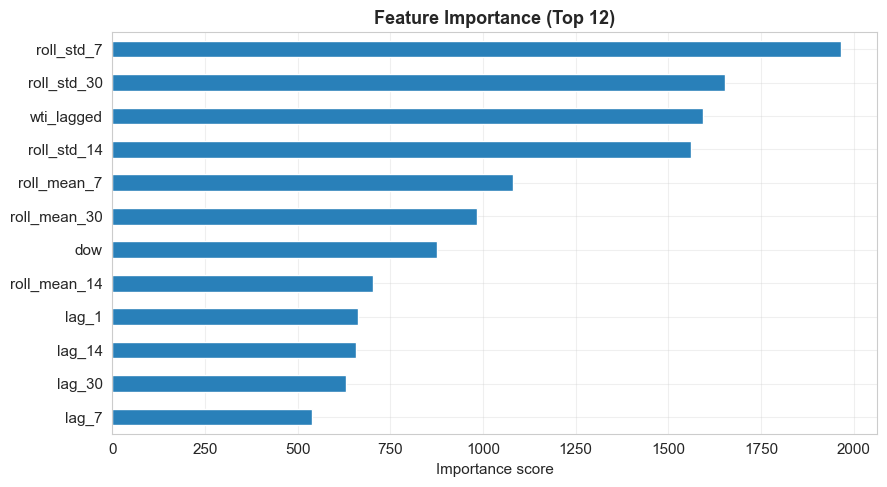

Ramadan indicator (purple) - its importance score vs. lag features shows domain signal value.


In [51]:
# Feature importance
if LGBM_AVAILABLE:
    importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True).tail(12)
    fig, ax = plt.subplots(figsize=(9, 5))
    colors = ['#8e44ad' if 'ramadan' in i else '#2980b9' for i in importances.index]
    importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.set_title('Feature Importance (Top 12)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance score')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Ramadan indicator (purple) - its importance score vs. lag features shows domain signal value.')

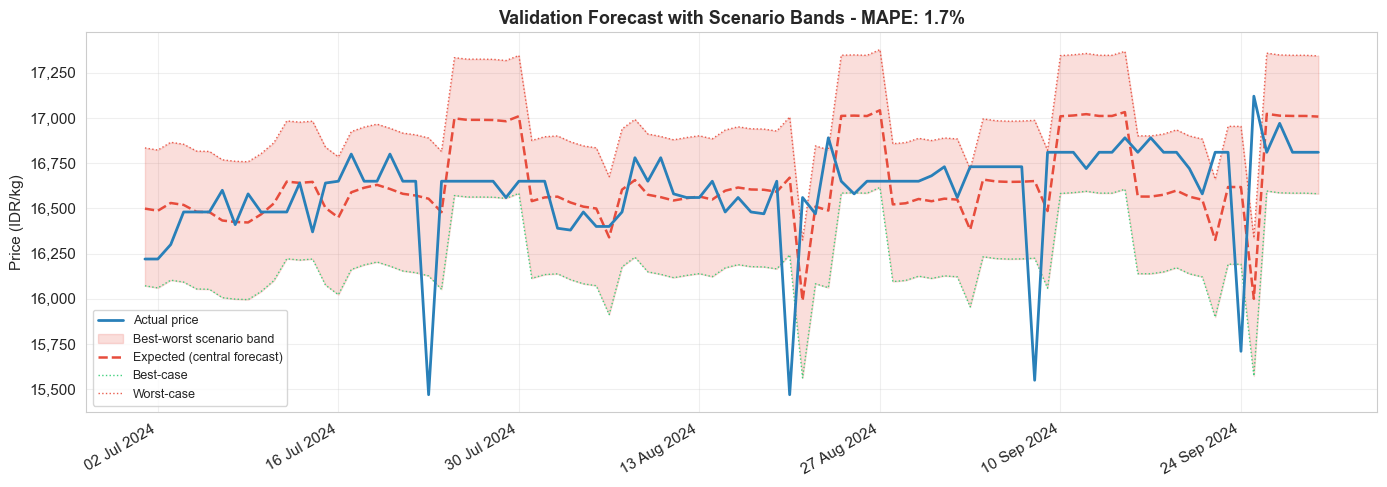

In [52]:
# Forecast on validation period with scenario bands derived from residual distribution
# Scenario interpretation:
#   Best-case  = model prediction + 5th percentile residual  (prices come in lower than expected)
#   Expected   = model prediction + 50th percentile residual (central estimate)
#   Worst-case = model prediction + 95th percentile residual (prices come in higher than expected)

pred_expected   = val_preds + res_p50
pred_best       = val_preds + res_p5
pred_worst      = val_preds + res_p95

fig, ax = plt.subplots(figsize=(14, 5))

# Actual
ax.plot(val.index, y_val, color='#2980b9', linewidth=2, label='Actual price', zorder=5)

# Scenario bands
ax.fill_between(val.index, pred_best, pred_worst,
                alpha=0.18, color='#e74c3c', label='Best-worst scenario band')
ax.plot(val.index, pred_expected, color='#e74c3c', linewidth=1.8,
        linestyle='--', label='Expected (central forecast)', zorder=4)
ax.plot(val.index, pred_best, color='#2ecc71', linewidth=1,
        linestyle=':', alpha=0.9, label='Best-case')
ax.plot(val.index, pred_worst, color='#e74c3c', linewidth=1,
        linestyle=':', alpha=0.9, label='Worst-case')

ax.set_ylabel('Price (IDR/kg)')
ax.set_title(f'Validation Forecast with Scenario Bands - MAPE: {val_mape:.1f}%', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('forecast_validation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Procurement Decision Layer

Section 5 provides a 30-day forecast plus residual-based uncertainty bounds. This section converts that forecast range into a **procurement decision**.

Two strategies are evaluated against a standardised monthly procurement volume of 10,000 kg:

| Strategy | Description |
|----------|-------------|
| **Buy Now** | Lock in full monthly volume at today's price |
| **Delay 30 Days** | Wait and purchase at the prevailing price in 30 days |

**Decision metric:** *Cost Risk Premium of Delaying* - the worst-case additional spend (95th percentile of forecast residuals) relative to buying today. A high risk premium in a high-volatility regime is the clearest signal to act now.

### 6.1 Historical Backtest

Before applying the framework to live data, we simulate it on two historical windows: a **declining-price period** (H2 2022) and a **stabilising period** (2023).

> **Note:** This is a hindsight simulation - it uses realised future prices to compute which strategy would have been cheaper. It shows that the regime-based framework is historically regime-responsive, but it does not validate the 30-day forecast accuracy. See Section 5 for out-of-sample forecast evaluation.

In [53]:
MONTHLY_VOLUME_KG = 10_000  # standardised procurement volume for cost simulation

def procurement_decision(df_window, label, volume_kg=MONTHLY_VOLUME_KG):
    """Simulate buy-now vs delay-30 for a given historical window."""
    results = []
    window = df_window.copy()

    for i in range(len(window) - 30):
        today = window.index[i]
        future_date = window.index[i + 30]
        price_now = window['mg_price'].iloc[i]
        price_future = window['mg_price'].iloc[i + 30]

        cost_now = price_now * volume_kg
        cost_future = price_future * volume_kg
        saving = cost_now - cost_future  # positive = delay was better
        pct_diff = (cost_future - cost_now) / cost_now * 100  # positive = buying now was better

        results.append({
            'date': today,
            'price_now': price_now,
            'price_future': price_future,
            'cost_now': cost_now,
            'cost_future': cost_future,
            'cost_diff_pct': pct_diff,
        })

    result_df = pd.DataFrame(results).set_index('date')

    delay_was_better = (result_df['cost_diff_pct'] < 0).mean() * 100
    avg_cost_diff = result_df['cost_diff_pct'].mean()
    worst_case_delay = result_df['cost_diff_pct'].quantile(0.95)

    print(f'\n--- {label} ---')
    print(f'Delay was cheaper       : {delay_was_better:.0f}% of 30-day windows')
    print(f'Average cost difference : {avg_cost_diff:+.1f}% (positive = buy now was cheaper)')
    print(f'Worst-case delay cost   : +{worst_case_delay:.1f}% vs buying now (95th percentile)')

    return result_df


# Window 1: Late 2022 - elevated and declining prices (post-palm-oil-crisis)
w1 = df[(df.index >= '2022-07-01') & (df.index <= '2022-12-31')]
r1 = procurement_decision(w1, 'Window 1: Jul-Dec 2022 (declining prices)')

# Window 2: 2023 - stable recovery period
w2 = df[(df.index >= '2023-01-01') & (df.index <= '2023-12-31')]
r2 = procurement_decision(w2, 'Window 2: Full year 2023 (stabilising prices)')


--- Window 1: Jul-Dec 2022 (declining prices) ---
Delay was cheaper       : 38% of 30-day windows
Average cost difference : -0.4% (positive = buy now was cheaper)
Worst-case delay cost   : +3.2% vs buying now (95th percentile)

--- Window 2: Full year 2023 (stabilising prices) ---
Delay was cheaper       : 39% of 30-day windows
Average cost difference : +0.2% (positive = buy now was cheaper)
Worst-case delay cost   : +4.9% vs buying now (95th percentile)


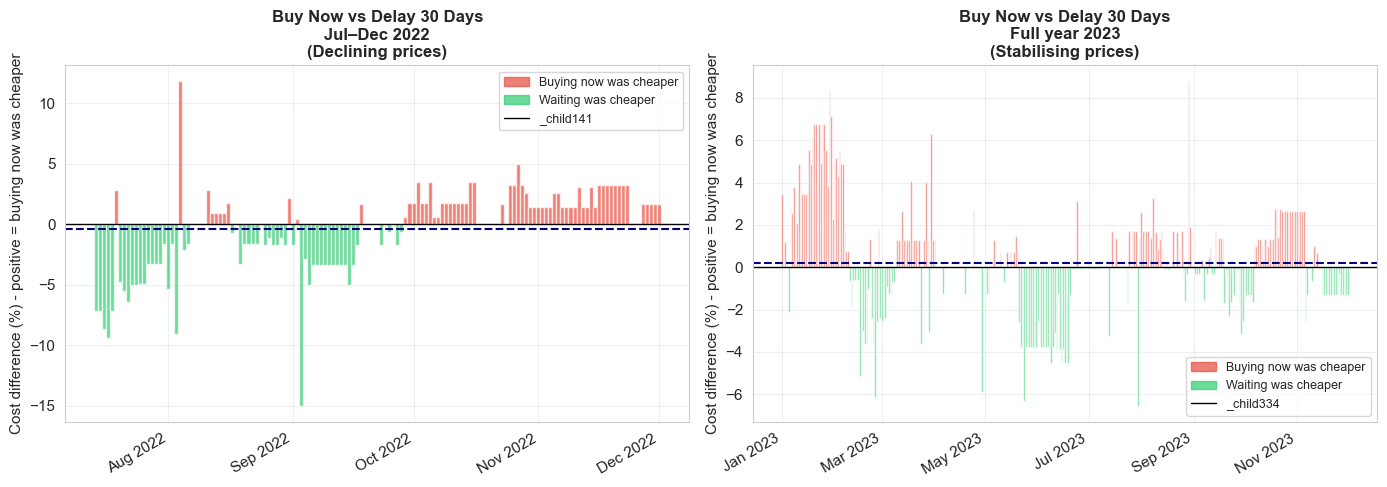

In [54]:
# Visualise cost difference distribution for both windows
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, result, title in zip(axes, [r1, r2],
                              ['Jul-Dec 2022\n(Declining prices)',
                               'Full year 2023\n(Stabilising prices)']):
    vals = result['cost_diff_pct']
    colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in vals]
    ax.bar(result.index, vals, color=colors, alpha=0.7, width=1)
    ax.axhline(0, color='black', linewidth=1)
    ax.axhline(vals.mean(), color='navy', linewidth=1.5, linestyle='--',
               label=f'Mean: {vals.mean():+.1f}%')
    ax.set_title(f'Buy Now vs Delay 30 Days\n{title}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Cost difference (%) - positive = buying now was cheaper')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend(fontsize=9)

    red_patch = mpatches.Patch(color='#e74c3c', alpha=0.7, label='Buying now was cheaper')
    green_patch = mpatches.Patch(color='#2ecc71', alpha=0.7, label='Waiting was cheaper')
    ax.legend(handles=[red_patch, green_patch, ax.lines[0]], fontsize=9)

plt.tight_layout()
plt.savefig('backtest_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Current Market Assessment & Recommendation

With the historical stress test and forecast evaluation in view, we now apply the decision layer to the most recent data point (September 2024).

In [55]:
# Current market state
lookback = 30
recent = df.tail(lookback)

current_price    = df['mg_price'].iloc[-1]
current_regime   = df['regime'].iloc[-1]
current_std      = df['rolling_std_30'].iloc[-1]
current_trend_30 = (df['mg_price'].iloc[-1] - df['mg_price'].iloc[-30]) / df['mg_price'].iloc[-30] * 100


def forecast_30days_recursive(model, df_feat, feature_cols, n_days=30):
    """Recursive one-step forecast chained over n_days.
    Each step's prediction feeds back as lag_1 for the next step.
    Recursive error accumulates - treat as indicative, not precise.
    WTI is held constant at its last known value (future WTI is unknown)."""
    hist = list(df_feat['mg_price'].iloc[-30:].values)
    last_row = df_feat[feature_cols].iloc[-1].copy().to_dict()
    base_date = df_feat.index[-1]
    preds = []

    for day in range(1, n_days + 1):
        future_date = base_date + pd.Timedelta(days=day)
        last_row['dow']    = future_date.dayofweek
        last_row['month']  = future_date.month
        last_row['week']   = int(future_date.isocalendar()[1])
        last_row['ramadan'] = 0

        last_row['lag_1']  = hist[-1]
        last_row['lag_7']  = hist[-7]  if len(hist) >= 7  else hist[0]
        last_row['lag_14'] = hist[-14] if len(hist) >= 14 else hist[0]
        last_row['lag_30'] = hist[-30] if len(hist) >= 30 else hist[0]

        w7  = hist[-7:]  if len(hist) >= 7  else hist
        w14 = hist[-14:] if len(hist) >= 14 else hist
        w30 = hist[-30:] if len(hist) >= 30 else hist
        last_row['roll_mean_7']  = float(np.mean(w7))
        last_row['roll_std_7']   = float(np.std(w7))  if len(w7)  > 1 else 0.0
        last_row['roll_mean_14'] = float(np.mean(w14))
        last_row['roll_std_14']  = float(np.std(w14)) if len(w14) > 1 else 0.0
        last_row['roll_mean_30'] = float(np.mean(w30))
        last_row['roll_std_30']  = float(np.std(w30)) if len(w30) > 1 else 0.0

        pred = float(model.predict(pd.DataFrame([last_row])[feature_cols])[0])
        preds.append(pred)
        hist.append(pred)

    return preds  # [day1, day2, ..., day30]


# 30-day model forecast
forecast_path = forecast_30days_recursive(model, df_feat, FEATURE_COLS)
price_day30   = forecast_path[-1]
price_direction = (price_day30 - current_price) / current_price * 100

# Scenario bands: use validation one-step residuals as a proxy for 30-day uncertainty.
# Actual 30-day uncertainty is wider (recursive error accumulates) - these are conservative bounds.
price_expected = price_day30
price_worst    = price_day30 + res_p95   # res_p95 = +553: worst 5% of val residuals
price_best     = price_day30 + res_p5    # res_p5 = -209: best 5% of val residuals

cost_now      = current_price  * MONTHLY_VOLUME_KG
cost_expected = price_expected * MONTHLY_VOLUME_KG
cost_worst    = price_worst    * MONTHLY_VOLUME_KG
cost_best     = price_best     * MONTHLY_VOLUME_KG

risk_premium  = (cost_worst - cost_now) / cost_now * 100

print('=' * 55)
print('  PROCUREMENT DECISION SUMMARY')
print('=' * 55)
print(f'  Analysis date       : {df.index[-1].date()}')
print(f'  Current price       : IDR {current_price:>10,.0f} /kg')
print(f'  Volatility regime   : {current_regime.upper()}')
print(f'  30-day trend        : {current_trend_30:+.1f}%')
print(f'  Model 30-day fcst   : IDR {price_day30:>10,.0f} /kg  ({price_direction:+.1f}%)')
print()
print(f'  STRATEGY A - Buy Now')
print(f'    Total cost         : IDR {cost_now:>12,.0f}')
print(f'    Price certainty    : 100% (locked in)')
print()
print(f'  STRATEGY B - Delay 30 Days')
print(f'    Model forecast     : IDR {cost_expected:>12,.0f}  ({(cost_expected-cost_now)/cost_now*100:+.1f}%)')
print(f'    Best-case          : IDR {cost_best:>12,.0f}  ({(cost_best-cost_now)/cost_now*100:+.1f}%)')
print(f'    Worst-case         : IDR {cost_worst:>12,.0f}  ({(cost_worst-cost_now)/cost_now*100:+.1f}%)')
print(f'    Cost risk premium  : {risk_premium:+.1f}% vs buying now (worst-case from val residuals)')
print()

# Decision rule: combines model 30-day direction with volatility regime
if current_regime == 'high' and price_direction > 2:
    recommendation = 'BUY NOW'
    rationale = (
        f'High volatility AND model forecasts +{price_direction:.1f}% price rise over 30 days. '
        f'Both signals favour locking in today.'
    )
elif current_regime == 'high' and price_direction < -2:
    recommendation = 'SPLIT PURCHASE (50% now, 50% in 15 days)'
    rationale = (
        f'High volatility but model forecasts a {price_direction:.1f}% decline. '
        f'Splitting hedges against further volatility while capturing some of the expected decline.'
    )
elif current_regime == 'low' and price_direction < -1:
    recommendation = 'DELAY'
    rationale = (
        f'Low volatility and model forecasts {price_direction:.1f}% price decline. '
        f'Low risk premium ({risk_premium:.1f}%) makes waiting attractive.'
    )
elif current_regime == 'low' and price_direction > 3:
    recommendation = 'BUY NOW'
    rationale = (
        f'Low volatility but model forecasts +{price_direction:.1f}% rise. '
        f'Pre-empt the anticipated increase while risk is contained.'
    )
else:
    recommendation = 'SPLIT PURCHASE (50% now, 50% in 15 days)'
    rationale = (
        f'Mixed signals: regime={current_regime}, model 30-day direction={price_direction:+.1f}%. '
        f'Splitting the purchase hedges both upside risk and foregone savings.'
    )

print(f'  RECOMMENDATION     : {recommendation}')
print(f'  Rationale          : {rationale}')
print()
print('  Disclaimer: The model was trained on data through Sep 2024.')
print('  Forecasts are indicative analytical outputs, not operational decisions.')
print('=' * 55)


  PROCUREMENT DECISION SUMMARY
  Analysis date       : 2024-09-30
  Current price       : IDR     16,810 /kg
  Volatility regime   : HIGH
  30-day trend        : +0.5%
  Model 30-day fcst   : IDR     16,464 /kg  (-2.1%)

  STRATEGY A - Buy Now
    Total cost         : IDR  168,100,000
    Price certainty    : 100% (locked in)

  STRATEGY B - Delay 30 Days
    Model forecast     : IDR  164,637,594  (-2.1%)
    Best-case          : IDR  162,545,165  (-3.3%)
    Worst-case         : IDR  170,165,242  (+1.2%)
    Cost risk premium  : +1.2% vs buying now (worst-case from val residuals)

  RECOMMENDATION     : SPLIT PURCHASE (50% now, 50% in 15 days)
  Rationale          : High volatility but model forecasts a -2.1% decline. Splitting hedges against further volatility while capturing some of the expected decline.

  Disclaimer: The model was trained on data through Sep 2024.
  Forecasts are indicative analytical outputs, not operational decisions.


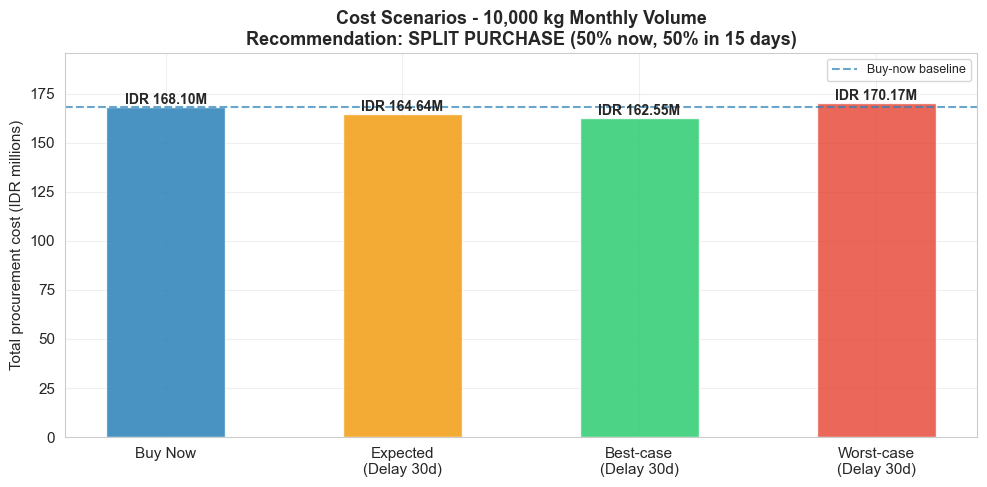

In [56]:
# Decision summary visualisation
strategies = ['Buy Now', 'Expected\n(Delay 30d)', 'Best-case\n(Delay 30d)', 'Worst-case\n(Delay 30d)']
costs = [cost_now, cost_expected, cost_best, cost_worst]
colors_bar = ['#2980b9', '#f39c12', '#2ecc71', '#e74c3c']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(strategies, [c / 1e6 for c in costs], color=colors_bar, alpha=0.85, edgecolor='white', width=0.5)

for bar, cost in zip(bars, costs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'IDR {cost/1e6:.2f}M',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(cost_now / 1e6, color='#2980b9', linewidth=1.5, linestyle='--', alpha=0.7, label='Buy-now baseline')
ax.set_ylabel('Total procurement cost (IDR millions)')
ax.set_title(f'Cost Scenarios - {MONTHLY_VOLUME_KG:,} kg Monthly Volume\nRecommendation: {recommendation}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, max(costs) / 1e6 * 1.15)
plt.tight_layout()
plt.savefig('decision_summary.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Conclusion

### What the numbers say

The analysis period (April 2022 - September 2024) captured a complete commodity price cycle: a sharp spike driven by global supply disruptions in 2022, a gradual normalisation through 2023, and a relatively stable but elevated-volatility environment entering Q4 2024.

Three findings stand out:

- **Seasonality is real and exploitable.** Cooking oil prices are consistently elevated during Ramadan (March-May). A procurement team that pre-purchases in February avoids this annual spike systematically, no model required, just calendar awareness.
- **WTI is not a reliable leading indicator for retail procurement timing.** The cross-correlation shows Jakarta retail prices moving *ahead* of WTI futures, not behind them. Local supply signals and the volatility regime are more actionable for short-horizon decisions.
- **The current market (September 2024) points to a split purchase rather than a full lock-in.** The market is still in a HIGH volatility regime, but the recursive 30-day model forecast is modestly negative (-2.1%), and the worst-case delay premium from validation residuals is only +1.2% on the monthly volume. That combination argues for hedging instead of making a single all-in timing call.

### Why this matters beyond a forecast

A procurement analyst who produces a forecast number is useful. One who translates uncertainty into a **cost risk premium**, and backs it with a simple stress-tested decision rule, is more useful.

The framework built here is intentionally simple. It requires historical price data, a volatility measure, and a clear definition of what "risk" means in operational terms. That combination is deployable in any commodity-heavy business: food distribution, industrial supply chains, or energy services.

### Portfolio connection

| Project | Decision question | Output |
|---------|-------------------|--------|
| Predictive Maintenance (C-MAPSS) | *When to fix an asset?* | Maintenance schedule with cost trade-offs |
| Commodity Procurement (this notebook) | *When to buy a resource?* | Buy / delay recommendation with IDR cost figures |

Both projects share the same discipline: **quantify uncertainty, define the cost of being wrong, then decide**. That is the skill that transfers from a data science notebook to an operational context.

### Limitations

- **Scope:** Single commodity and market. This notebook does not cover cross-province or multi-commodity generalisation.
- **Decision layer:** Two strategies only. A production system would add staggered purchasing, inventory holding costs, and supplier contract constraints.
- **WTI relationship:** Observational. A structural model of the palm oil -> cooking oil -> retail price transmission chain would strengthen the causal story.